In [385]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib.patches as mpatches


In [386]:
df = pd.read_csv(r"F:\AnalystLabAfrica\Titanic-Dataset.csv")
df.head(5)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Data Understanding**

In [387]:
print(f"The shape of the data: {df.shape} \n")
print(f"The data has {df.duplicated().sum()} duplicae values \n")
print(f"Number of dimension: {df.ndim} \n")
print(f"The size of the data: {df.size} \n")
print(f"The columns in the data: {df.columns} \n")
print(f"Data info: {df.info()} \n")


The shape of the data: (891, 12) 

The data has 0 duplicae values 

Number of dimension: 2 

The size of the data: 10692 

The columns in the data: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object') 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtyp

**Dropping Useless Columns**

In [388]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'],inplace = True)

# Exploratory Data Analysis

**Univariate Analysis**

C:\Users\DELL\AppData\Local\Temp\ipykernel_9936\3275987074.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  flat_axes[1].set_xticklabels(['Deceased','Survived'])
C:\Users\DELL\AppData\Local\Temp\ipykernel_9936\3275987074.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  flat_axes[5].set_xticklabels(['Southampton','Cherbourg', 'Queenstown'])


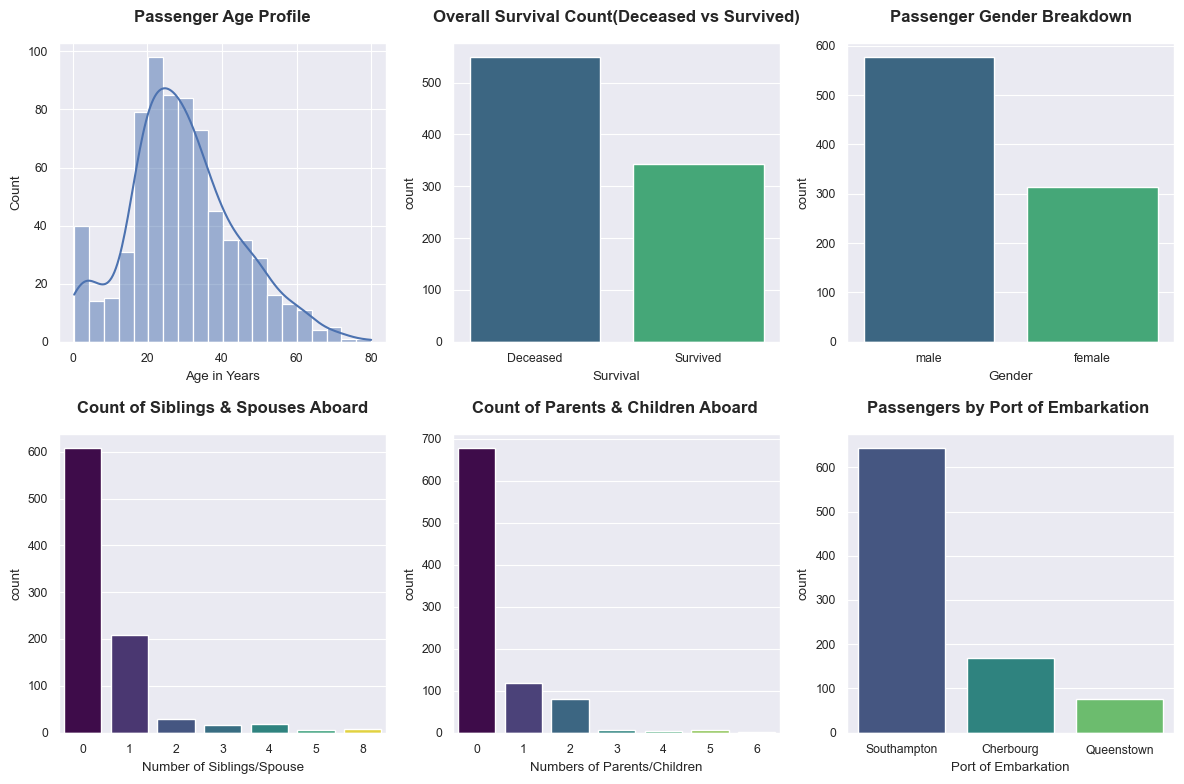

In [389]:
# Defining the columns to be plotted in order
cols = ['Age','Survived','Sex','SibSp','Parch','Embarked']
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12,8))
sns.set_style('whitegrid')
sns.set_context('notebook')
# Flattening the axes array for easy indexing
flat_axes = axes.flatten()

# Looping through columns and axes simutaneously
for i, col in enumerate(cols):
    if col == 'Age':
        sns.histplot(data = df, x = col,ax = flat_axes[i], bins = 20,kde =True)
    else:
        sns.countplot(data = df, x = col,ax = flat_axes[i],palette =  'viridis', hue = col, legend = False)

flat_axes[0].set(title = 'Passenger Age Profile', xlabel = 'Age in Years')
flat_axes[1].set(title = 'Overall Survival Count(Deceased vs Survived)', xlabel = 'Survival')
flat_axes[2].set(title = 'Passenger Gender Breakdown', xlabel = 'Gender')
flat_axes[3].set(title = 'Count of Siblings & Spouses Aboard', xlabel = 'Number of Siblings/Spouse')
flat_axes[4].set(title = 'Count of Parents & Children Aboard ', xlabel = 'Numbers of Parents/Children')
flat_axes[5].set(title = 'Passengers by Port of Embarkation ', xlabel = 'Port of Embarkation')
flat_axes[1].set_xticklabels(['Deceased','Survived'])
flat_axes[5].set_xticklabels(['Southampton','Cherbourg', 'Queenstown'])
plt.tight_layout()
plt.show()



**Bivariate Analysis**

C:\Users\DELL\AppData\Local\Temp\ipykernel_9936\2022187297.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1][0].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])


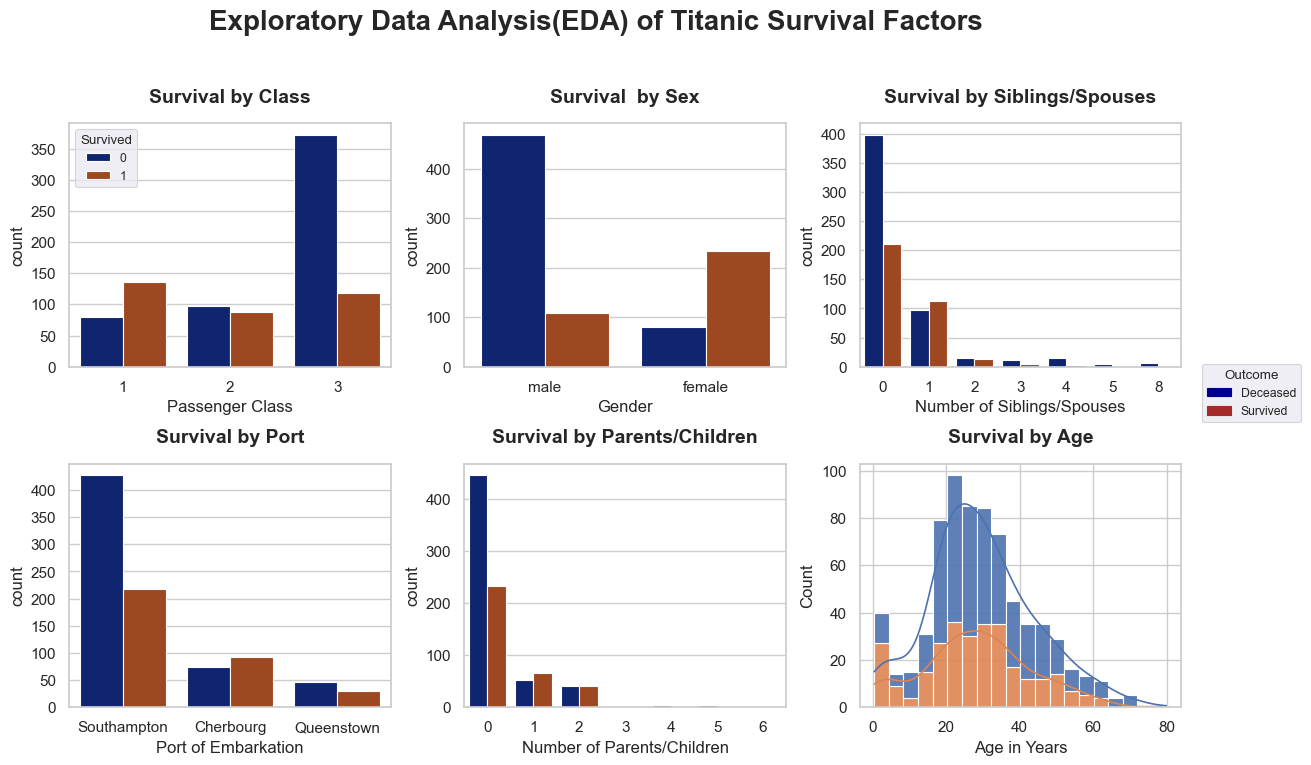

In [390]:
# initializing  2x3 grid for side-by-side comparison
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize= (12,8))
# seting the visual style for all plots
sns.set_theme(context= 'paper', style = 'darkgrid')
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

#  Categorical Features analysis 
# Investigating how survival varies across Class, Sex and family relations
sns.countplot(data = df, x = 'Pclass',hue = 'Survived',palette = 'dark',ax = axes[0][0])
axes[0][0].set(title ="Survival by Class",xlabel = 'Passenger Class')

sns.countplot(data = df, x = 'Sex',hue = 'Survived',palette = 'dark',ax = axes[0][1], legend = False)
axes[0][1].set(title ="Survival  by Sex", xlabel = 'Gender')

sns.countplot(data = df, x = 'SibSp',hue = 'Survived',palette = 'dark',ax = axes[0][2], legend = False)
axes[0][2].set(title ="Survival by Siblings/Spouses", xlabel = 'Number of Siblings/Spouses')

sns.countplot(data = df, x = 'Embarked', hue = 'Survived',palette = 'dark',ax = axes[1][0], legend = False)
axes[1][0].set(title ="Survival by Port", xlabel = 'Port of Embarkation')
axes[1][0].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])

sns.countplot(data = df, x = 'Parch',hue = 'Survived',palette = 'dark',ax = axes[1][1], legend = False)
axes[1][1].set(title ="Survival by Parents/Children", xlabel = 'Number of Parents/Children')


# Numerical Feature analysis
# Using a stacked histogram to see age distribution within survival groups
sns.histplot(data = df, x = 'Age',hue = 'Survived',multiple = 'stack',  ax = axes[1][2],alpha = 0.9,kde = True, legend = False)
axes[1][2].set(title = "Survival by Age", xlabel = 'Age in Years')

no_patch = mpatches.Patch(color = "darkblue", label  = 'Deceased')
yes_patch = mpatches.Patch(color = 'brown', label  = 'Survived')

fig.legend(handles = [no_patch, yes_patch], loc = 'center left', bbox_to_anchor = (1,0.5), title = 'Outcome', frameon = True)
plt.suptitle('Exploratory Data Analysis(EDA) of Titanic Survival Factors', fontsize = 20, fontweight = 'bold')
plt.tight_layout(rect = (0, 0.03, 1, 0.95)) #Adjusting layout to prevent overlapping titles
plt.show()


**key insights**

Most passengers boarded at Southampton (S) which also saw the highest number of deaths. Passengers who boarded at Cherbourg (C) had a higher survival rate relative to their total count compared to the two other part\
The histogram shows the majority of passengers were adults between the ages of 20 and 40 where the mortality rate was higher\
**Females had a significantly higher survival rate than males**\
**Passengers in 1st class(1) had the best chance of survival,3rd classs (3) had the highest overall number of passengers and the highest number of casualties**\
Passengers traveling alone made the largest group. While they had the highest number of survivors, they also had the highest number of deaths. Having a small family(1 or 2 members) seemed to slightly improve the likelihood of survival compared to being alone or having a very large family

**Summary**:

The data confirms that **Sex** and **Pclass** are the two most critical factors in determinig who survived the disaster

# Check for Outliers

<Axes: xlabel='Fare'>

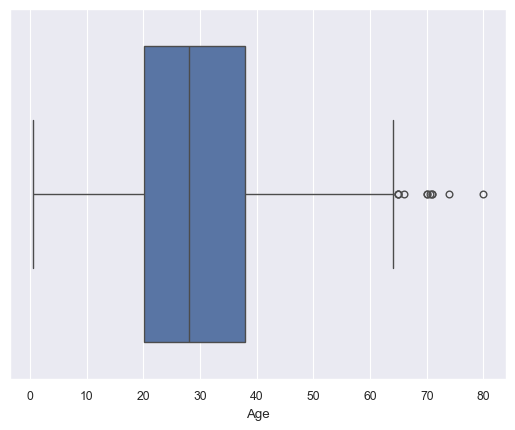

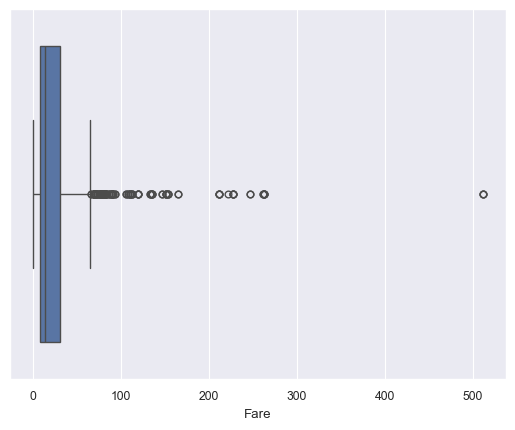

In [391]:
sns.boxplot(data = df, x = 'Age') #Checks for outliers in the age columns
plt.figure()
sns.boxplot(data = df, x = 'Fare') # Checks for outliers in the Fare columns



The above boxplots shows that there are outliers in the **Age** and **Fare** columns

# Missing Values

**Before handling missing values**

C:\Users\DELL\AppData\Local\Temp\ipykernel_9936\3591605755.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])


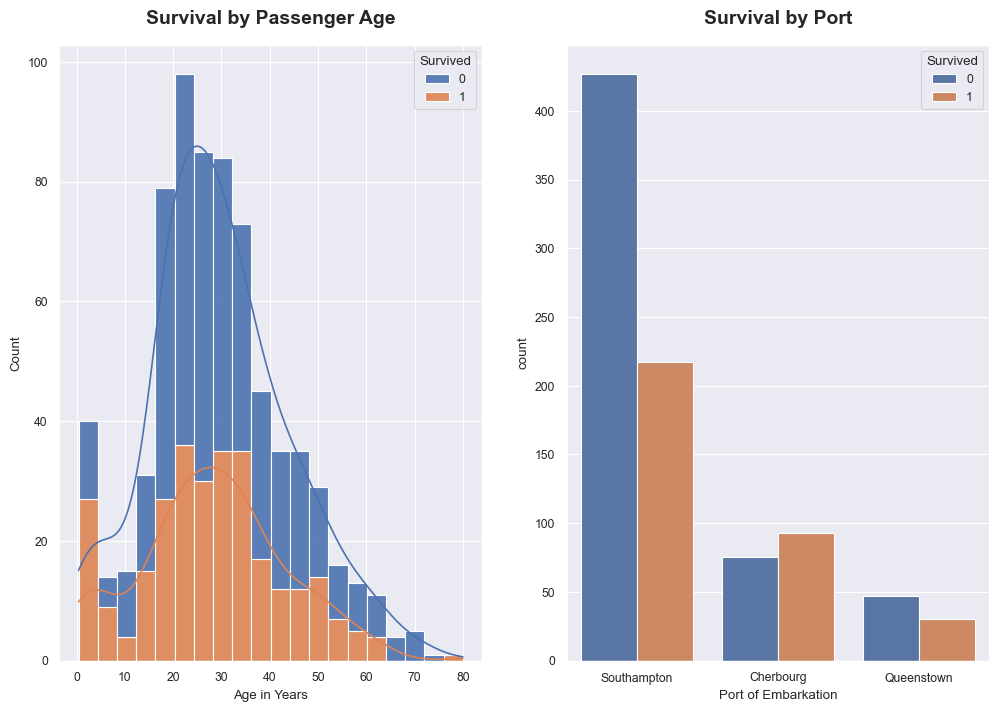

In [392]:

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize =(12,8))

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

sns.histplot(data = df, x = 'Age',hue = 'Survived',multiple = 'stack',alpha = 0.9,kde = True, ax = axes[0])
axes[0].set(title = "Survival by Passenger Age",xlabel = 'Age in Years')

sns.countplot(data = df, x = 'Embarked',hue = 'Survived', ax = axes[1])
axes[1].set(title = "Survival by Port", xlabel = 'Port of Embarkation')
axes[1].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])


plt.show()

In [393]:
print(f"TOTAL NUMBER OF MISSING VALUES IN EACH COLUMN \n\n {df.isnull().sum()} missing values")

TOTAL NUMBER OF MISSING VALUES IN EACH COLUMN 

 Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64 missing values


In [394]:

# Missing values filled with median because the age histogram shows a slightly right-skewed distribution
df['Age'] = df['Age'].fillna(df['Age'].median()) 

# Missing values filled with mode because the Embarked column only contains 2 missing values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) 

**Afer Handling Missing Values**

C:\Users\DELL\AppData\Local\Temp\ipykernel_9936\1132970233.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])


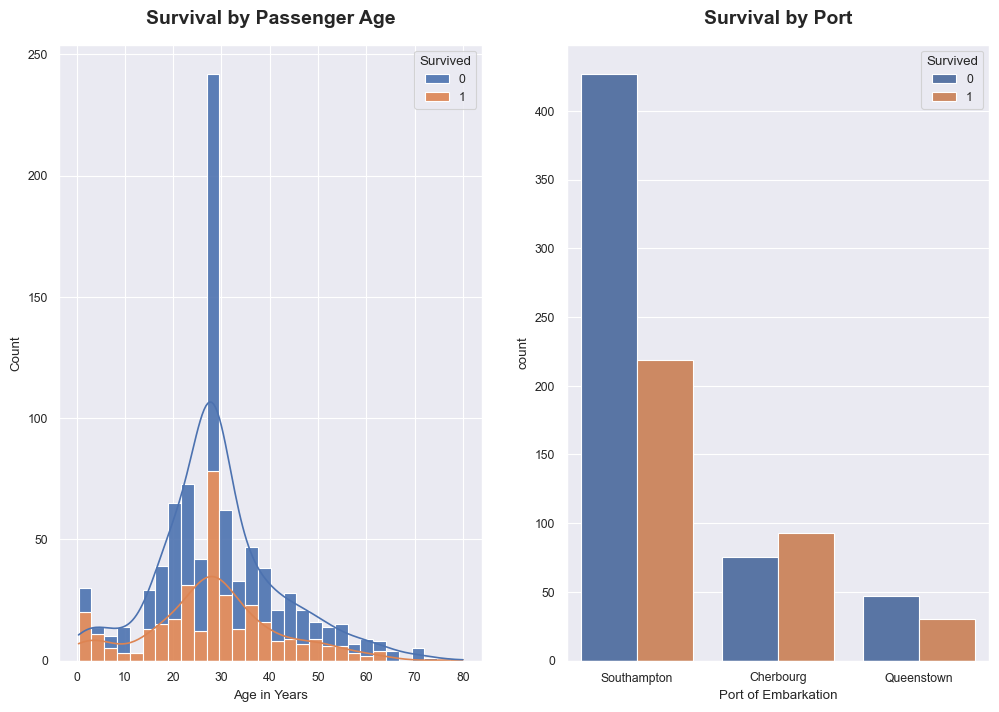

In [395]:
# After handling missing values

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize =(12,8))

plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 15

sns.histplot(data = df, x = 'Age',hue = 'Survived',multiple = 'stack',alpha = 0.9,kde = True, ax = axes[0])
axes[0].set(title = "Survival by Passenger Age",xlabel = 'Age in Years')

sns.countplot(data = df, x = 'Embarked',hue = 'Survived', ax = axes[1])
axes[1].set(title = "Survival by Port", xlabel = 'Port of Embarkation')
axes[1].set_xticklabels(['Southampton', 'Cherbourg', 'Queenstown'])


plt.show()


# Encoding Categorical Variables

In [396]:
# Label encoding is sufficient for the sex 
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0}) 


In [397]:
# One-Hot encoding for the Embarked column
df = pd.get_dummies(df, columns = ['Embarked'], drop_first=True)

**Correlation heatmap**

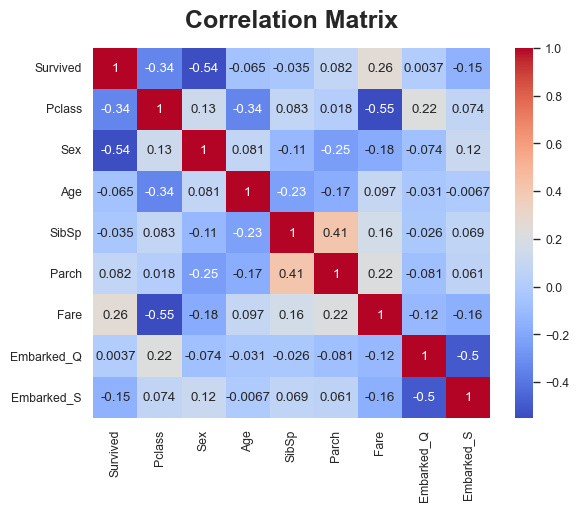

In [398]:
corr = df.corr()
sns.heatmap(corr,annot = True,  cmap = 'coolwarm').set(title = 'Correlation Matrix')
plt.title('Correlation Matrix', fontsize = 18, fontweight = 'bold')
plt.show()

**Data Scaling/Standardization**

In [399]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
# Selecting the numerical columns that need to be scaled
cols_to_scale = ['Age','Fare']

#Fitting and transforming only those columns, then updating the dataframe

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])
df.describe()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,8.910000e+02,891.000000,891.000000,8.910000e+02
mean,0.383838,2.308642,0.647587,2.272780e-16,0.523008,0.381594,3.987333e-18
std,0.486592,0.836071,0.477990,1.000562e+00,1.102743,0.806057,1.000562e+00
min,0.000000,1.000000,0.000000,-2.224156e+00,0.000000,0.000000,-6.484217e-01
25%,0.000000,2.000000,0.000000,-5.657365e-01,0.000000,0.000000,-4.891482e-01
50%,0.000000,3.000000,1.000000,-1.046374e-01,0.000000,0.000000,-3.573909e-01
75%,1.000000,3.000000,1.000000,4.333115e-01,1.000000,0.000000,-2.424635e-02
max,1.000000,3.000000,1.000000,3.891554e+00,8.000000,6.000000,9.667167e+00
